# OBRISI XEVE I NABAVI VAZNE ATRIBUTE

In [1]:
import os
from Bio import SeqIO
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


def run_ensemble_with_features(repeats_folder, train_folder, test_folder,
                               report_file = None,
                               top_features = 20):
    """
    Train and evaluate an ensemble classifier on protein sequences using repeat counts as features.
    Also computes and plots most important repeats.

    Parameters
    ----------
    repeats_folder : str
        Folder with repeats (CSV-like files: label,repeat).
    train_folder : str
        Folder with training FASTA files.
    test_folder : str
        Folder with test FASTA files.
    report_file : str
        File to save classification report.
    top_features : int
        Number of most important features (repeats) to display/plot.

    Returns
    -------
    ensemble : VotingClassifier
        Trained ensemble model.
    encoder : LabelEncoder
        Fitted label encoder.
    known_repeats : list
        List of repeat features used.
    """

    # ----------------------------
    # Load known repeats
    # ----------------------------
    repeats = []
    for file in os.listdir(repeats_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(repeats_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])

    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    # ----------------------------
    # Load training data
    # ----------------------------
    X_train, y_train = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        label = os.path.basename(file).replace(".fasta", "")
        for record in SeqIO.parse(filepath, "fasta"):
            X_train.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_train.append(label)

    # ----------------------------
    # Load test data
    # ----------------------------
    X_test, y_test = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        label = os.path.basename(file).replace(".fasta", "")
        for record in SeqIO.parse(filepath, "fasta"):
            X_test.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_test.append(label)

    # ----------------------------
    # Encode labels
    # ----------------------------
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_test_enc = encoder.transform(y_test)

    # ----------------------------
    # Define classifiers
    # ----------------------------
    clf_rf = RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )

    clf_xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42
    )

    clf_mlp = MLPClassifier(
        hidden_layer_sizes=(200,),
        max_iter=500,
        random_state=42
    )

    ensemble = VotingClassifier(
        estimators=[('rf', clf_rf), ('xgb', clf_xgb), ('mlp', clf_mlp)],
        voting='soft'
    )

    # ----------------------------
    # Train ensemble
    # ----------------------------
    print("Training ensemble...")
    ensemble.fit(X_train, y_train_enc)

    # ----------------------------
    # Predictions
    # ----------------------------
    y_pred_enc = ensemble.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)

    y_pred_enc_train = ensemble.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    report = classification_report(y_test, y_pred)
    print("Classification report:")
    print(report)
    print("Accuracy score test:", accuracy_score(y_test, y_pred))
    print("Accuracy score train:", accuracy_score(y_train, y_pred_train))

    with open(report_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(accuracy_score(y_test, y_pred)))
        f.write("\nAccuracy score train: " + str(accuracy_score(y_train, y_pred_train)))

    # ----------------------------
    # Feature importances (average RF + XGB)
    # ----------------------------
    rf_fitted = ensemble.named_estimators_["rf"]
    xgb_fitted = ensemble.named_estimators_["xgb"]

    rf_importances = rf_fitted.feature_importances_
    xgb_importances = xgb_fitted.feature_importances_
    importances = (rf_importances + xgb_importances) / 2.0

    indices = np.argsort(importances)[::-1]

    print(f"\nTop {top_features} most important features (repeats):")
    for i in range(min(top_features, len(indices))):
        repeat = known_repeats[indices[i]]
        importance = importances[indices[i]]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), importances[indices[:top_features]], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in indices[:top_features]], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (RF + XGB)")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

    return ensemble, encoder, known_repeats


Number of unique repeats: 990
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:02:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.95      0.97      0.96       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.99      0.98      0.99       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      0.83      0.91         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

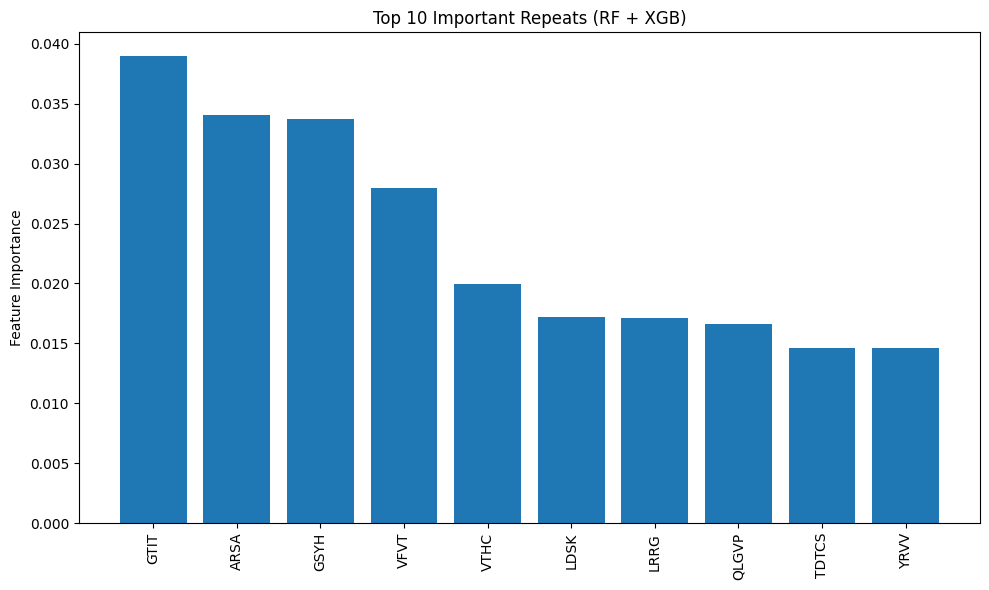

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [2]:
run_ensemble_with_features("../proba2/direct",
                          "../trainSet",
                          "../testSet",
                          "classification_report_comb_direct_2.txt", 10)

Number of unique repeats: 1495
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:07:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      0.99      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.98      0.96      0.97       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.96      0.99      0.97       536
  ferret-CoV       1.00      0.92      0.96        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

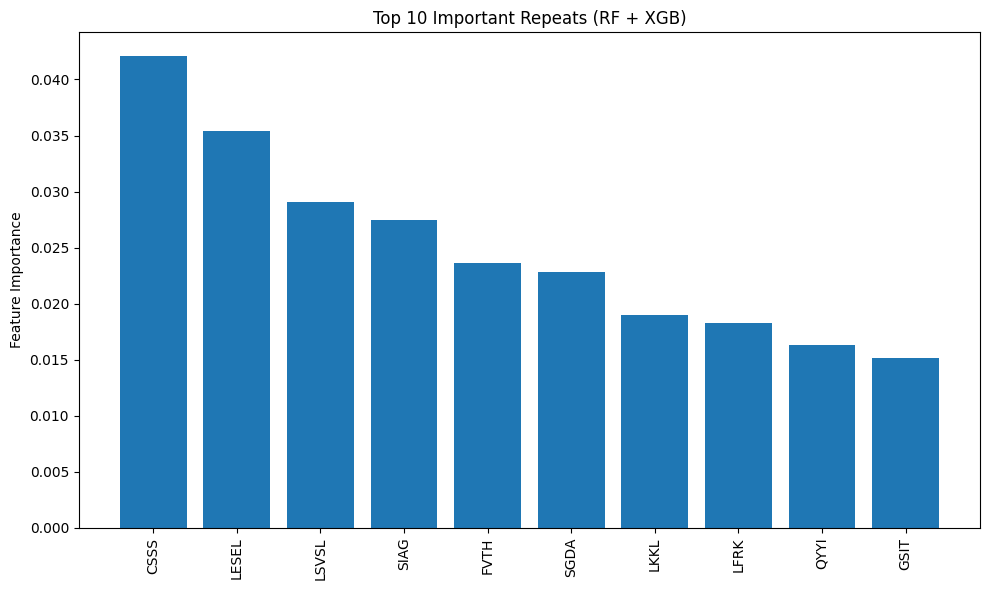

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [3]:
run_ensemble_with_features("../proba2/indirect",
                          "../trainSet",
                          "../testSet",
                          "classification_report_comb_indirect_2.txt", 10)

Number of unique repeats: 982
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:12:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      0.99        94
   HCoV-HKU1       1.00      0.98      0.99        56
   HCoV-NL63       0.99      1.00      1.00       103
   HCoV-OC43       1.00      0.99      1.00       196
         IBV       1.00      1.00      1.00      2097
    MERS-CoV       1.00      0.99      0.99       138
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       1.00      1.00      1.00       661
     bat-CoV       1.00      1.00      1.00        12
  bovine-CoV       0.99      1.00      1.00       245
  canine-CoV       0.94      0.95      0.94       143
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.98      0.99      0.99       389
  ferret-CoV       1.00      1.00      1.00         9
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00        99
  ra

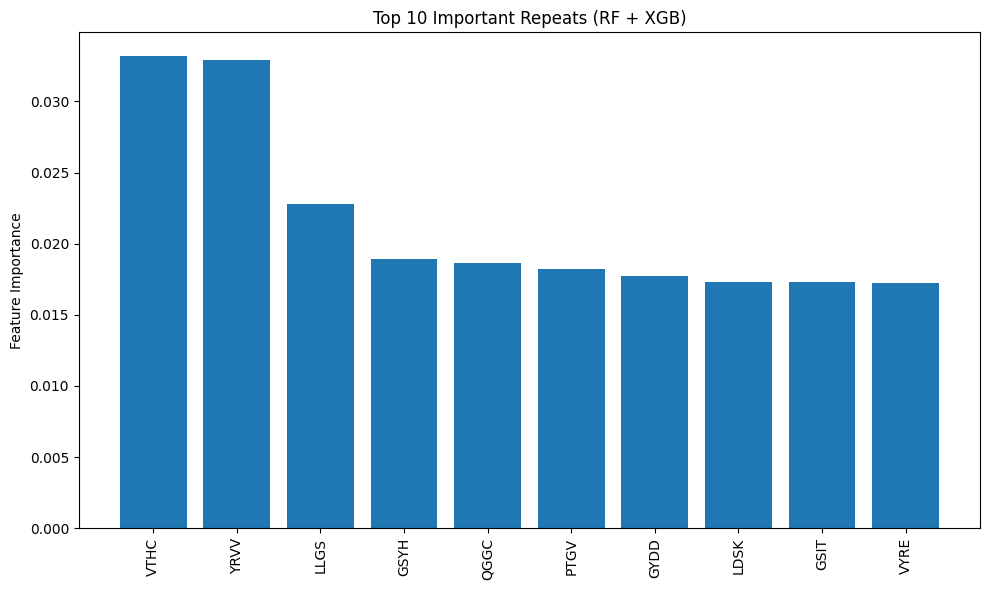

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [4]:
run_ensemble_with_features("../proba2NoDuplicates/direct",
                          "../trainSetNoDuplicates",
                          "../testSetNoDuplicates",
                          "classification_report_comb_direct_no_duplicates_2.txt", 10)

Number of unique repeats: 1478
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:16:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99        94
   HCoV-HKU1       1.00      0.98      0.99        56
   HCoV-NL63       0.98      1.00      0.99       103
   HCoV-OC43       1.00      0.99      1.00       196
         IBV       1.00      1.00      1.00      2097
    MERS-CoV       1.00      0.99      0.99       138
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       1.00      1.00      1.00       661
     bat-CoV       1.00      1.00      1.00        12
  bovine-CoV       0.99      1.00      0.99       245
  canine-CoV       0.99      0.94      0.96       143
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.96      1.00      0.98       389
  ferret-CoV       1.00      0.89      0.94         9
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00        99
  ra

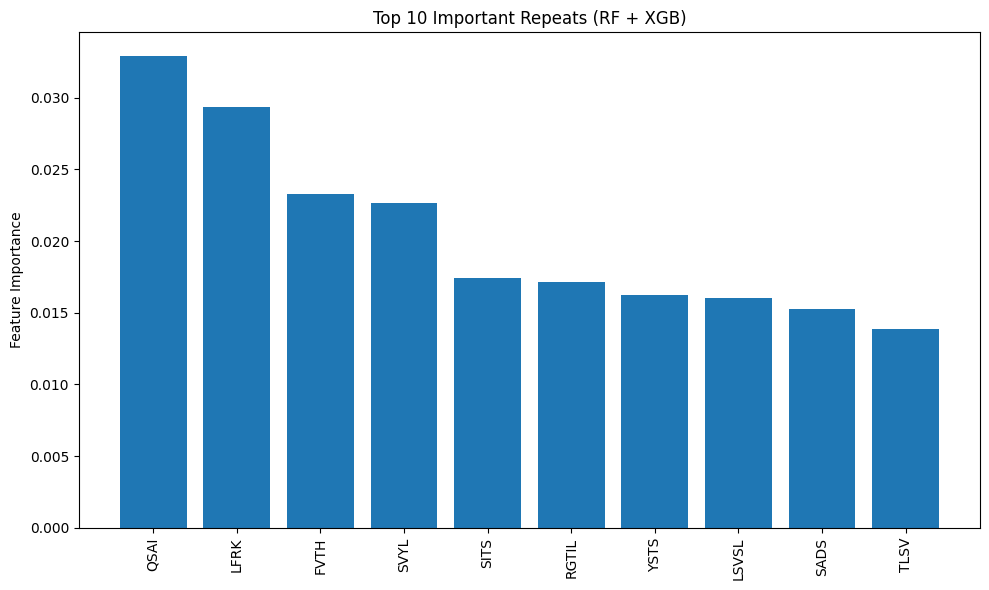

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [5]:
run_ensemble_with_features("../proba2NoDuplicates/indirect",
                          "../trainSetNoDuplicates",
                          "../testSetNoDuplicates",
                          "classification_report_comb_indirect_no_duplicates_2.txt", 10)

Number of unique repeats: 4509
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:36:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       120
   HCoV-HKU1       1.00      0.99      0.99        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      1.00      1.00       252
         IBV       1.00      1.00      1.00      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.97      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       0.99      1.00      1.00       276
  canine-CoV       0.98      0.95      0.97       162
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.98      0.97      0.98       444
  ferret-CoV       1.00      1.00      1.00        11
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00       108
  ra

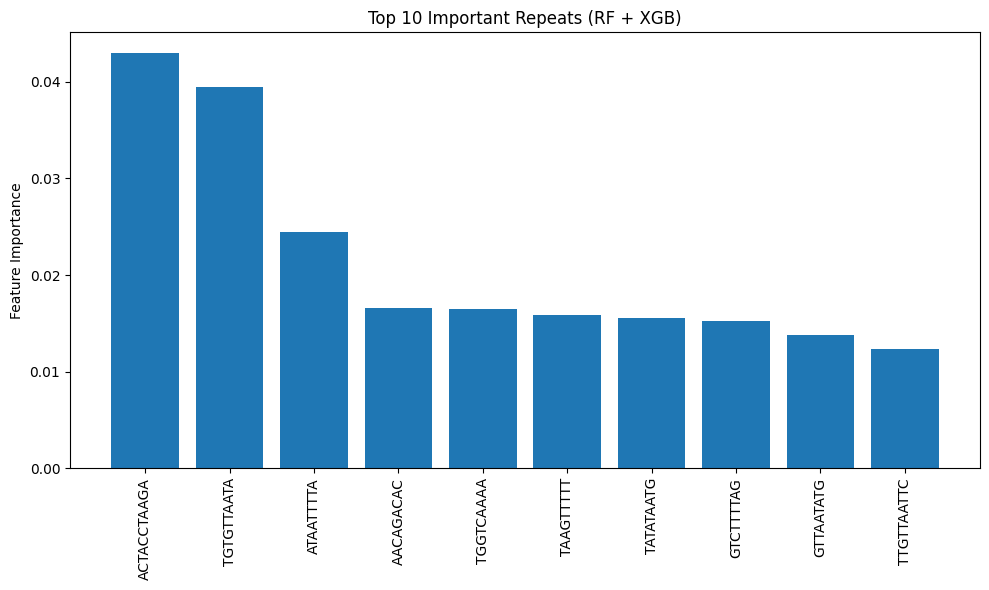

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [6]:
run_ensemble_with_features("../proba2NoDuplicatesNucl/DC",
                          "../trainSetNoDuplicatesNucl",
                          "../testSetNoDuplicatesNucl",
                          "classification_report_comb_DC_no_duplicates_2.txt", 10)

Number of unique repeats: 6144
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       120
   HCoV-HKU1       1.00      0.99      0.99        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      1.00      1.00       252
         IBV       1.00      1.00      1.00      2267
    MERS-CoV       1.00      0.99      1.00       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.99      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       0.99      1.00      1.00       276
  canine-CoV       0.97      0.96      0.97       162
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.99      0.99      0.99       444
  ferret-CoV       1.00      1.00      1.00        11
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00       108
  ra

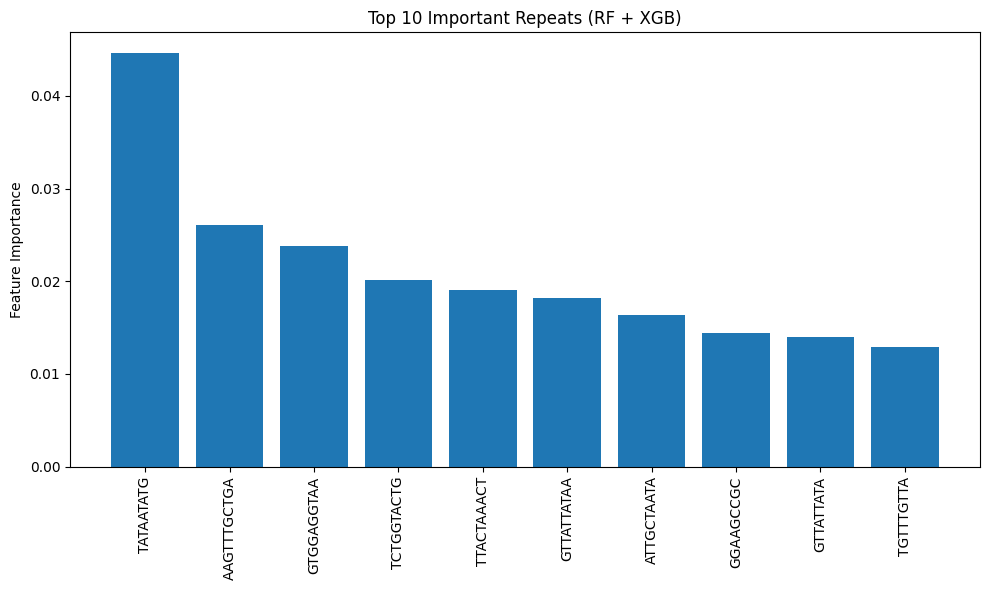

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [7]:
run_ensemble_with_features("../proba2NoDuplicatesNucl/IC",
                          "../trainSetNoDuplicatesNucl",
                          "../testSetNoDuplicatesNucl",
                          "classification_report_comb_IC_no_duplicates_2.txt", 10)

Number of unique repeats: 6346
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:45:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       120
   HCoV-HKU1       1.00      0.99      0.99        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      1.00      1.00       252
         IBV       1.00      1.00      1.00      2267
    MERS-CoV       1.00      0.99      1.00       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.98      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       0.99      1.00      1.00       276
  canine-CoV       0.99      0.96      0.97       162
 dolphin-CoV       1.00      0.50      0.67         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.99      0.99      0.99       444
  ferret-CoV       1.00      1.00      1.00        11
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00       108
  ra

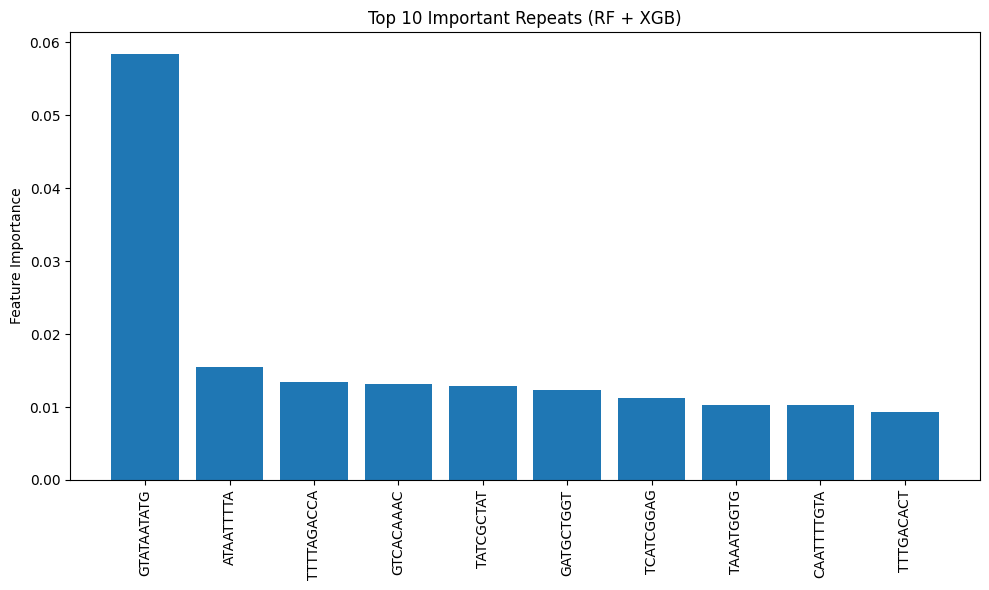

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [8]:
run_ensemble_with_features("../proba2NoDuplicatesNucl/IN",
                          "../trainSetNoDuplicatesNucl",
                          "../testSetNoDuplicatesNucl",
                          "classification_report_comb_IN_no_duplicates_2.txt", 10)

Number of unique repeats: 8047
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:10:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       120
   HCoV-HKU1       1.00      0.99      0.99        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      1.00      1.00       252
         IBV       1.00      1.00      1.00      2267
    MERS-CoV       1.00      0.99      1.00       198
    SARS-CoV       1.00      1.00      1.00         2
   SARS-CoV2       0.98      1.00      0.99       624
     bat-CoV       1.00      1.00      1.00        13
  bovine-CoV       1.00      1.00      1.00       276
  canine-CoV       0.98      0.94      0.96       162
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.98      0.99      0.99       444
  ferret-CoV       1.00      1.00      1.00        11
hedgehog-CoV       1.00      1.00      1.00         5
 porcine-CoV       1.00      1.00      1.00       108
  ra

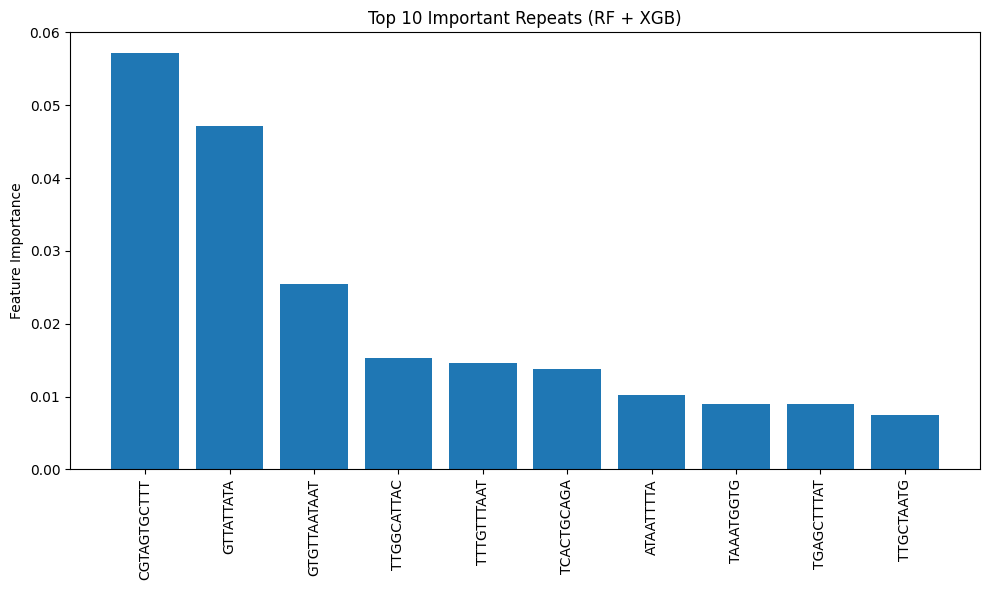

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [9]:
run_ensemble_with_features("../proba2NoDuplicatesNucl/DN",
                          "../trainSetNoDuplicatesNucl",
                          "../testSetNoDuplicatesNucl",
                          "classification_report_comb_DN_no_duplicates_2.txt", 10)

Number of unique repeats: 11921
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:08:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      1.00      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.97      1.00      0.98       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.99      0.99      0.99       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

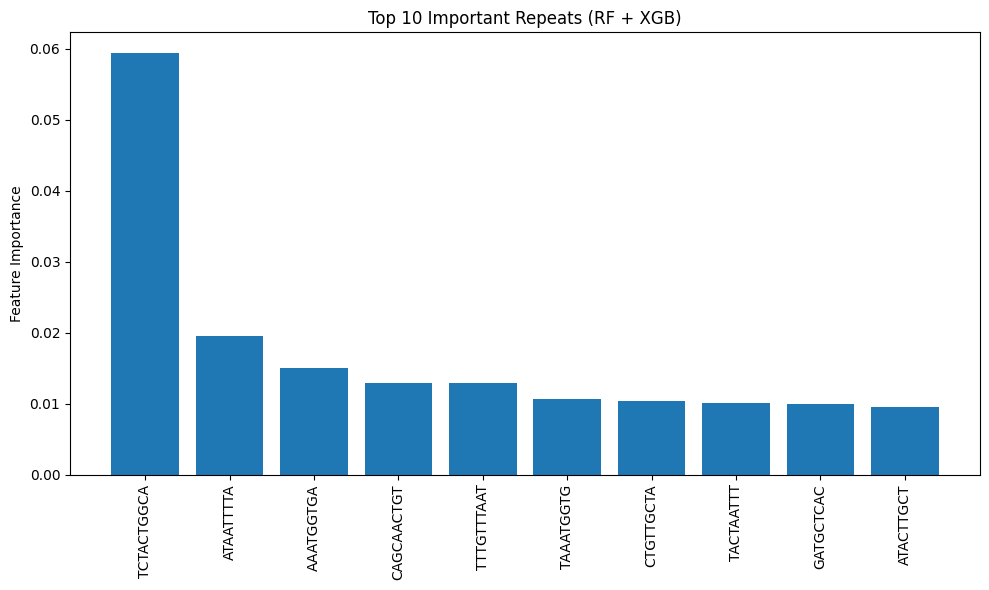

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [10]:
run_ensemble_with_features("../proba3/DN",
                          "../trainSetNucl",
                          "../testSetNucl",
                          "classification_report_comb_DN_2.txt", 10)

Number of unique repeats: 6993
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:39:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      0.99      0.99       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.97      0.98      0.97       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.98      0.99      0.98       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

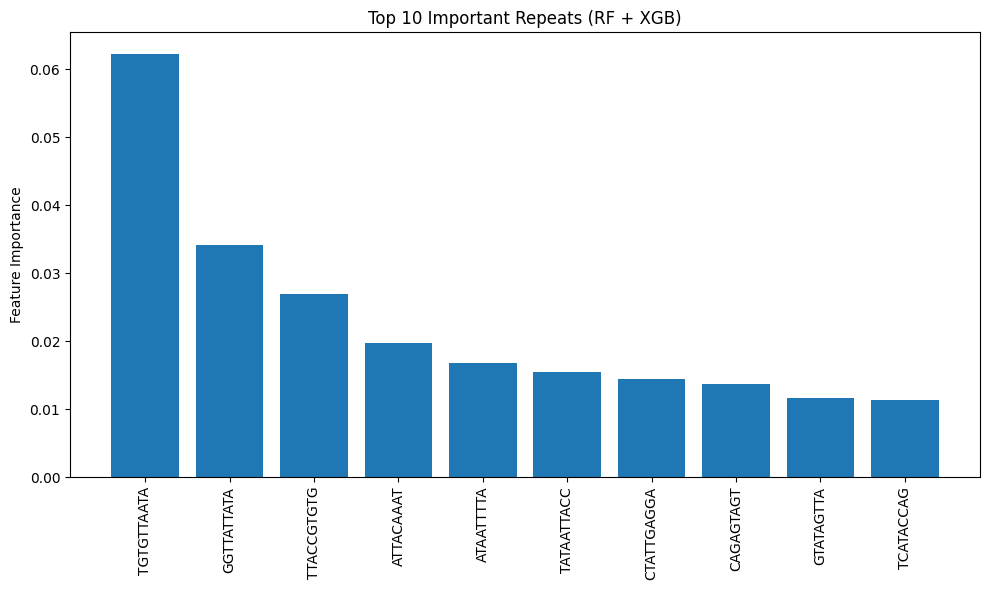

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [2]:
run_ensemble_with_features("../proba3/DC",
                          "../trainSetNucl",
                          "../testSetNucl",
                          "classification_report_comb_DC_2.txt", 10)

Number of unique repeats: 9258
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:48:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      1.00      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.97      1.00      0.98       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.99      0.99      0.99       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

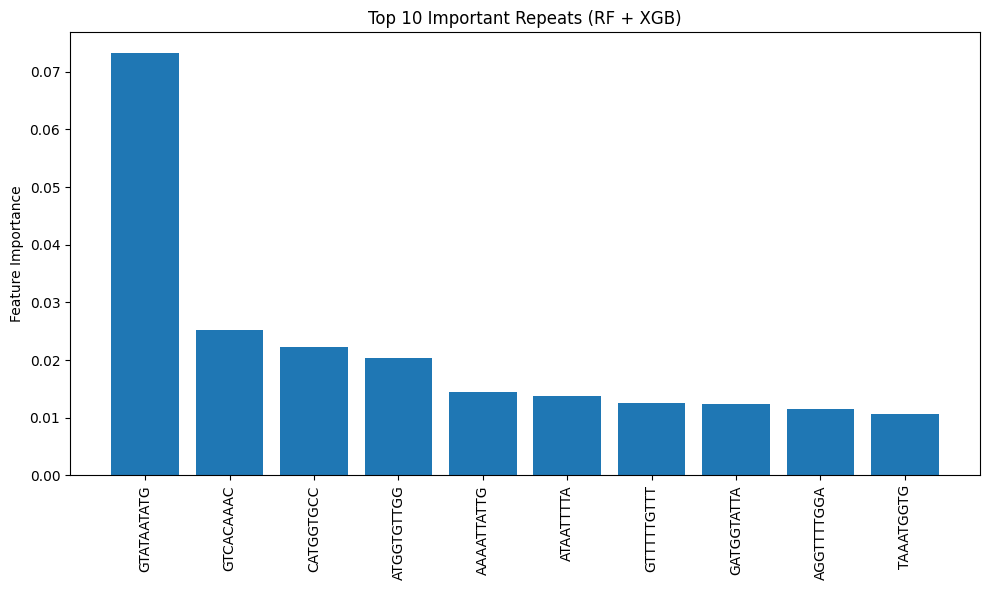

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [3]:
run_ensemble_with_features("../proba3/IN",
                          "../trainSetNucl",
                          "../testSetNucl",
                          "classification_report_comb_IN_2.txt", 10)

Number of unique repeats: 9112
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:39:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.98      0.99       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      1.00      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      0.99      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.97      0.99      0.98       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.50      0.67         8
  feline-CoV       0.99      0.99      0.99       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

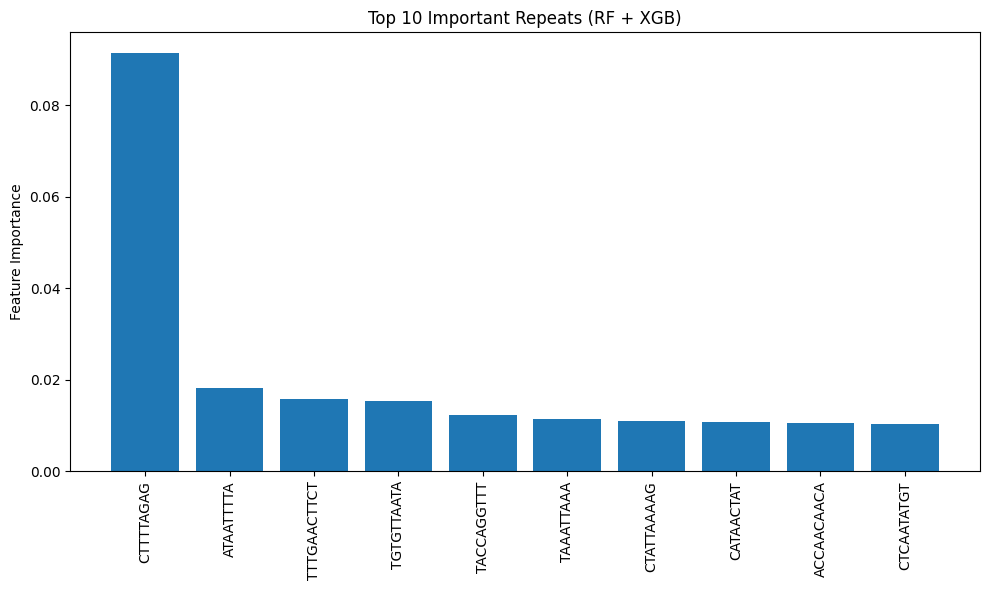

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [4]:
run_ensemble_with_features("../proba3/IC",
                          "../trainSetNucl",
                          "../testSetNucl",
                          "classification_report_comb_IC_2.txt", 10)

In [1]:
import os
from Bio import SeqIO
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


def run_ensemble_with_features(repeats_folder, train_folder, test_folder,
                               report_file = None,
                               top_features = 20):
    """
    Train and evaluate an ensemble classifier on protein sequences using repeat counts as features.
    Also computes and plots most important repeats.

    Parameters
    ----------
    repeats_folder : str
        Folder with repeats (CSV-like files: label,repeat).
    train_folder : str
        Folder with training FASTA files.
    test_folder : str
        Folder with test FASTA files.
    report_file : str
        File to save classification report.
    top_features : int
        Number of most important features (repeats) to display/plot.

    Returns
    -------
    ensemble : VotingClassifier
        Trained ensemble model.
    encoder : LabelEncoder
        Fitted label encoder.
    known_repeats : list
        List of repeat features used.
    """

    # ----------------------------
    # Load known repeats
    # ----------------------------
    repeats = []
    for file in os.listdir(repeats_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(repeats_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])

    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    # ----------------------------
    # Load training data
    # ----------------------------
    X_train, y_train = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        label = os.path.basename(file).replace(".fasta", "")
        for record in SeqIO.parse(filepath, "fasta"):
            X_train.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_train.append(label)

    # ----------------------------
    # Load test data
    # ----------------------------
    X_test, y_test = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        label = os.path.basename(file).replace(".fasta", "")
        for record in SeqIO.parse(filepath, "fasta"):
            X_test.append(extract_repeat_counts(str(record.seq), known_repeats))
            y_test.append(label)

    # ----------------------------
    # Encode labels
    # ----------------------------
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_test_enc = encoder.transform(y_test)

    # ----------------------------
    # Define classifiers
    # ----------------------------
    clf_rf = RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )

    clf_xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42
    )

    clf_mlp = MLPClassifier(
        hidden_layer_sizes=(200,),
        max_iter=500,
        random_state=42
    )

    ensemble = VotingClassifier(
        estimators=[('rf', clf_rf), ('xgb', clf_xgb), ('mlp', clf_mlp)],
        voting='soft'
    )

    # ----------------------------
    # Train ensemble
    # ----------------------------
    print("Training ensemble...")
    ensemble.fit(X_train, y_train_enc)

    # ----------------------------
    # Predictions
    # ----------------------------
    y_pred_enc = ensemble.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)

    y_pred_enc_train = ensemble.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    report = classification_report(y_test, y_pred)
    print("Classification report:")
    print(report)
    print("Accuracy score test:", accuracy_score(y_test, y_pred))
    print("Accuracy score train:", accuracy_score(y_train, y_pred_train))

    with open(report_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(accuracy_score(y_test, y_pred)))
        f.write("\nAccuracy score train: " + str(accuracy_score(y_train, y_pred_train)))

    # ----------------------------
    # Feature importances (average RF + XGB)
    # ----------------------------
    rf_fitted = ensemble.named_estimators_["rf"]
    xgb_fitted = ensemble.named_estimators_["xgb"]

    rf_importances = rf_fitted.feature_importances_
    xgb_importances = xgb_fitted.feature_importances_
    importances = (rf_importances + xgb_importances) / 2.0

    indices = np.argsort(importances)[::-1]

    print(f"\nTop {top_features} most important features (repeats):")
    for i in range(min(top_features, len(indices))):
        repeat = known_repeats[indices[i]]
        importance = importances[indices[i]]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), importances[indices[:top_features]], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in indices[:top_features]], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (RF + XGB)")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

    return ensemble, encoder, known_repeats


Number of unique repeats: 1979
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:19:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.99      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      1.00       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      1.00       375
  canine-CoV       0.95      0.97      0.96       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.99      0.98      0.99       536
  ferret-CoV       1.00      1.00      1.00        13
hedgehog-CoV       1.00      0.83      0.91         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

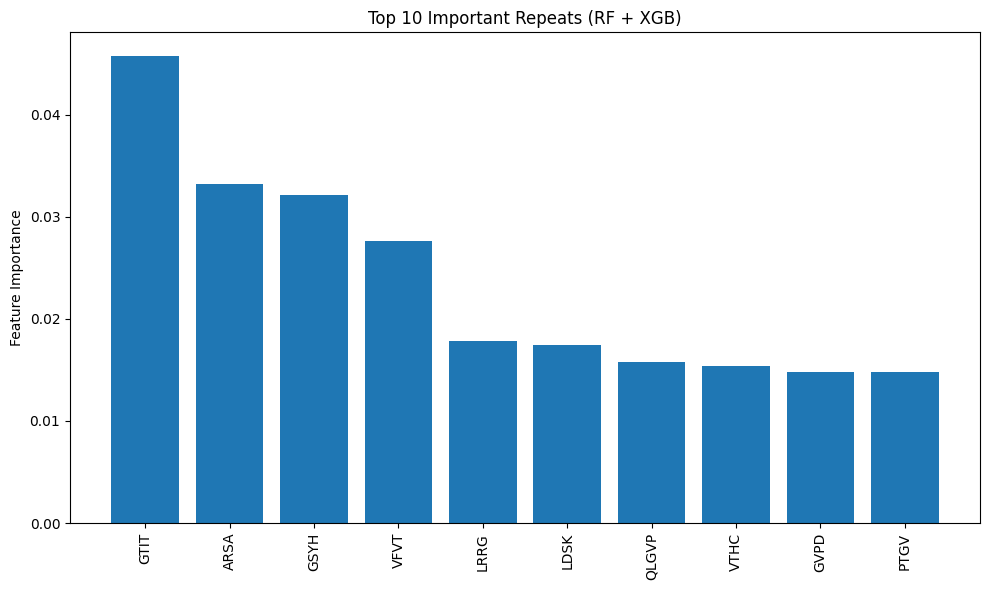

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [2]:
run_ensemble_with_features("../proba2/direct",
                          "../trainSet",
                          "../testSet",
                          "probaSa2Ponovka_direct.txt", 10)

Number of unique repeats: 2989
Training ensemble...


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:34:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      0.99      1.00       395
    SARS-CoV       1.00      1.00      1.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.98      0.96      0.97       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.96      0.99      0.97       536
  ferret-CoV       1.00      0.92      0.96        13
hedgehog-CoV       1.00      1.00      1.00         6
 porcine-CoV       1.00      1.00      1.00       132
  ra

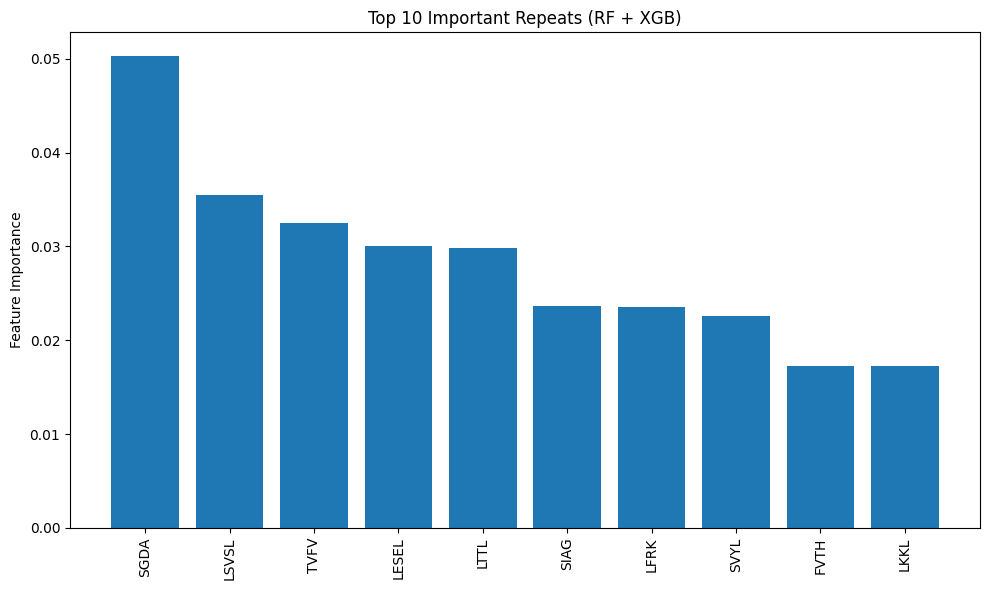

(VotingClassifier(estimators=[('rf',
                               RandomForestClassifier(n_estimators=200,
                                                      n_jobs=-1,
                                                      random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='mlogloss',
                                             feature_types=None,
                                             feature_we...
                        

In [3]:
run_ensemble_with_features("../proba2/indirect",
                          "../trainSet",
                          "../testSet",
                          "probaSa2Ponovka_indirect.txt", 10)